# ПІДГОТОВКА НАБОРУ ДАНИХ
## 1.1 Вибір та завантаження набору даних

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_log_error,
    d2_absolute_error_score,
    r2_score
)

In [121]:
# завантаження набору даних
df = pd.read_csv("../data/car_prices.csv")
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## 1.2 Базова підготовка даних

1. перевіряємо пропуски (за потреби заповнюємо їх медіаною або модою);
2. перевіряємо типи даних;
3. фільтруємо аномальні значення;
4. обираємо числові ознаки та цільову змінну.


In [122]:
# перевірка пропусків
missing_before = df.isna().sum()
missing_before[missing_before > 0]

make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
condition       11820
odometer           94
color             749
interior          749
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [125]:
# заповнення пропусків (числові колонки - медіана, категоріальні - мода)

for col in df.columns:
    if df[col].isna().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            mode_val = df[col].mode()
            if not mode_val.empty:
                df[col] = df[col].fillna(mode_val.iloc[0])

# перевірка пропусків після заповнення
missing_after = df.isna().sum()
missing_after[missing_after > 0]

Series([], dtype: int64)

In [126]:
df.dtypes

year              int64
make                str
model               str
trim                str
body                str
transmission        str
vin                 str
state               str
condition       float64
odometer        float64
color               str
interior            str
seller              str
mmr             float64
sellingprice    float64
saledate            str
dtype: object

In [127]:
# відслідковуємо аномалії/екстримальні значення
df = df[
    (df["year"] <= 2026) &
    (df["odometer"] >= 0) &
    (df["mmr"] > 0)
].copy()

### Вибір ознак і цільової змінної

Для побудови моделей використаємо **5 числових ознак**:

- `year`
- `condition`
- `odometer`
- `mmr`
- `sellingprice`

Цільова змінна:

- `sellingprice`


In [128]:
# формуємо набір числових колонок для аналізу
feature_cols = [
    "year",
    "condition",
    "odometer",
    "mmr",
]
target_col = "sellingprice"

analysis_df = df[feature_cols + [target_col]].copy()
analysis_df.head()

,year,condition,odometer,mmr,sellingprice
0,2015,5.0,16639.0,20500.0,21500.0
1,2015,5.0,9393.0,20800.0,21500.0
2,2014,45.0,1331.0,31900.0,30000.0
3,2015,41.0,14282.0,27500.0,27750.0
4,2014,43.0,2641.0,66000.0,67000.0


## 1.3 Знаходження залежностей
Під **сильною кореляцією** будемо розуміти
**|r| ≥ 0.8**.

Якщо дві ознаки дуже сильно корелюють між собою, одну з них краще прибрати, щоб зменшити мультиколінеарність.


In [129]:
# кореляційна матриця для набору даних
corr = analysis_df.corr(numeric_only=True)
corr

,year,condition,odometer,mmr,sellingprice
year,1.000000,0.323564,-0.772415,0.596594,0.586474
condition,0.323564,1.000000,-0.304580,0.273153,0.313120
odometer,-0.772415,-0.304580,1.000000,-0.587958,-0.582267
mmr,0.596594,0.273153,-0.587958,1.000000,0.983634
sellingprice,0.586474,0.313120,-0.582267,0.983634,1.000000


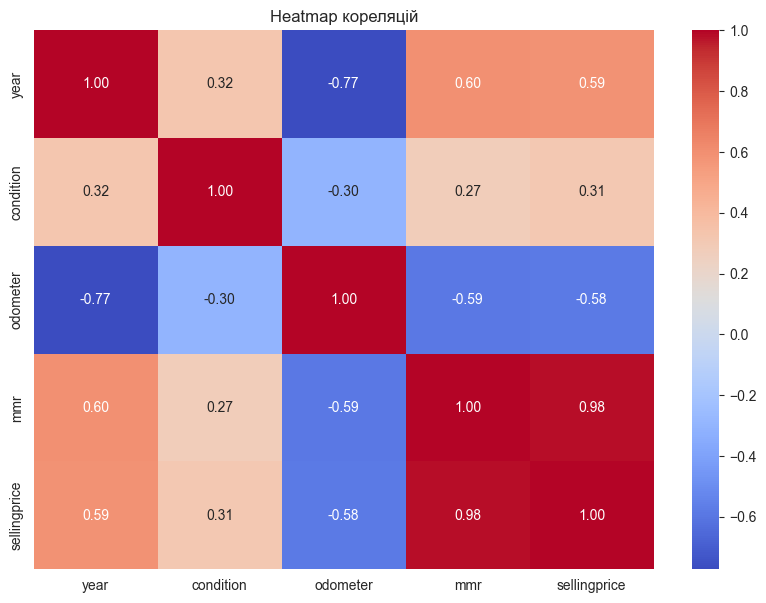

In [130]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap кореляцій")
plt.show()

In [113]:
# ознаки упорядковані за силою зв'язку з цільовою змінною (`sellingprice`)
# `Виведіть ознаки у порядку сили зв’язку із цільовою змінною.`
target_corr = corr[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False)
target_corr

mmr          0.983634
year         0.586474
odometer    -0.582267
condition    0.313120
Name: sellingprice, dtype: float64

In [131]:
# пошук сильно корельованих пар ознак (між самими ознаками)
strong_threshold = 0.8
feature_corr = analysis_df[feature_cols].corr(numeric_only=True).abs()

strong_pairs = []
for i, col1 in enumerate(feature_corr.columns):
    for j, col2 in enumerate(feature_corr.columns):
        if j > i and feature_corr.loc[col1, col2] >= strong_threshold:
            strong_pairs.append((col1, col2, feature_corr.loc[col1, col2]))

strong_pairs

[]

**Висновок:**

Найбільш пов’язаною з цільовою змінною ознакою є та, що має найбільше абсолютне значення коефіцієнта кореляції. Якщо між ознаками немає пар із |r| ≥ 0.8, усі вибрані ознаки можна залишити.

Для поділу на навчальну і тестову вибірки раціонально використати 80/20, оскільки:
  - 80% даних для навчання
  - 20% даних для коректної перевірки якості

In [133]:
# Поділ на train/test
X = analysis_df[feature_cols].copy()
y = analysis_df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=57
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (447069, 4)
X_test: (111768, 4)
y_train: (447069,)
y_test: (111768,)


# ЗАВДАННЯ 2. ПОБУДОВА РЕГРЕСІЙНИХ МОДЕЛЕЙ

**Службові функції для оцінювання моделей та уникнення дублювання**
- для обчислення метрик;
- для побудови графіків;
- для запуску експериментів.


In [138]:
def safe_msle(y_true, y_pred):
    # якщо в прогнозі з'являються від'ємні числа, обрізаємо їх до нуля (MSLE лише невід'ємні)
    y_pred_safe = np.clip(y_pred, a_min=0, a_max=None)
    y_true_safe = np.clip(y_true, a_min=0, a_max=None)
    return mean_squared_log_error(y_true_safe, y_pred_safe)

def full_metrics_dict(y_true_train, y_pred_train, y_true_test, y_pred_test):
    return {
        "Train_R2": r2_score(y_true_train, y_pred_train),
        "Test_R2": r2_score(y_true_test, y_pred_test),
        "Train_MAE": mean_absolute_error(y_true_train, y_pred_train),
        "Test_MAE": mean_absolute_error(y_true_test, y_pred_test),
        "Train_MSLE": safe_msle(y_true_train, y_pred_train),
        "Test_MSLE": safe_msle(y_true_test, y_pred_test),
        "Train_D2": d2_absolute_error_score(y_true_train, y_pred_train),
        "Test_D2": d2_absolute_error_score(y_true_test, y_pred_test),
    }

def plot_single_model_predictions(
    x_train_feature, x_test_feature,
    y_train_true, y_test_true,
    y_train_pred, y_test_pred,
    feature_name, model_name
):
    plt.figure(figsize=(11, 6))

    # реальні точки
    plt.scatter(x_train_feature, y_train_true, alpha=0.35, label="Train actual", marker="o")
    plt.scatter(x_test_feature, y_test_true, alpha=0.35, label="Test actual", marker="x")

    # прогнози
    plt.plot(np.array(x_train_feature), np.array(y_train_pred),
             label="Train prediction", linewidth=2)
    plt.plot(np.array(x_test_feature), np.array(y_test_pred),
             label="Test prediction", linewidth=2, linestyle="--")

    plt.xlabel(feature_name)
    plt.ylabel(target_col)
    plt.title(f"{model_name}: реальні значення та прогнози")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 2.1 Проста лінійна регресія

In [147]:
# навчання моделі LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

train_score = lin_model.score(X_train, y_train)
test_score = lin_model.score(X_test, y_test)

# прогнози
y_train_pred_lin = lin_model.predict(X_train)
y_test_pred_lin = lin_model.predict(X_test)

# метрики
metrics_21 = pd.DataFrame([full_metrics_dict(y_train, y_train_pred_lin, y_test, y_test_pred_lin)])
metrics_21.index = ["2.1 LinearRegression"]
metrics_21["Train_R2_score"] = train_score
metrics_21["Test_R2_score"] = test_score
metrics_21

,Train_R2,Test_R2,Train_MAE,Test_MAE,Train_MSLE,Test_MSLE,Train_D2,Test_D2,Train_R2_score,Test_R2_score
2.1 LinearRegression,0.969675,0.970231,1053.109394,1063.877124,0.206299,0.19957,0.849929,0.848828,0.969675,0.970231


In [140]:
# найбільш пов'язана з цільовою змінною ознака
top_feature = target_corr.index[0]
top_feature

'mmr'

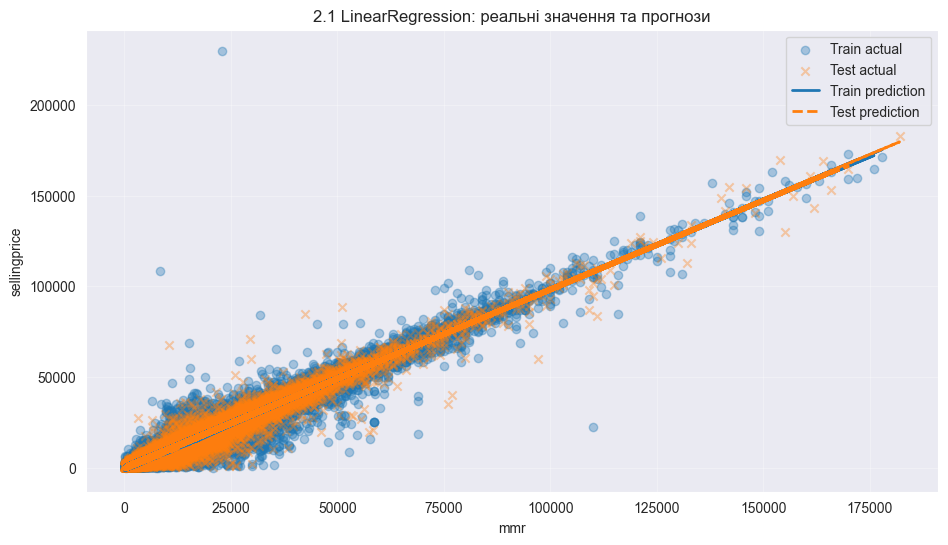

In [141]:
plot_single_model_predictions(
    X_train[top_feature], X_test[top_feature],
    y_train, y_test,
    y_train_pred_lin, y_test_pred_lin,
    top_feature, "2.1 LinearRegression"
)

**Короткий висновок до 2.1**
- `R^2` показує, яку частку варіації цільової змінної пояснює модель.
- `MAE` (Mean absolute error) показує середню абсолютну помилку прогнозу в тих самих одиницях, що й `sellingprice`.
- `MSLE` (Mean squared logarithmic error) зручно інтерпретувати для невід’ємних даних.
- `D^2 absolute error score` є альтернативною метрикою якості для регресії.

За графіком можна побачити, наскільки щільно прогнози наближаються до реальних значень, що для тренувальної так і для тестової вибірок, з невеликими відхиленнями. З датафрейму метрик, виведених раніше, можна зробити висновок про високу пояснювальну здатність моделі, оскільки значення R^2 ~ 0.9 -> 1 , різниця train & test вибірок сигналізують про відсутність перенавчання, MAE > 1000 сигналізує про високу точність

## 2.2 Проста лінійна регресія з перетворенням змінних
Перед навчанням виконуємо перетворення всіх змінних до більш нормального розподілу (використано `PowerTransformer`)

In [142]:
# перетворення X до більш нормального розподілу
pt_X = PowerTransformer()

# навчання
X_train_pt = pt_X.fit_transform(X_train)
X_test_pt = pt_X.transform(X_test)

lin_model_pt = LinearRegression()
lin_model_pt.fit(X_train_pt, y_train)

train_score_pt = lin_model_pt.score(X_train_pt, y_train)
test_score_pt = lin_model_pt.score(X_test_pt, y_test)

y_train_pred_lin_pt = lin_model_pt.predict(X_train_pt)
y_test_pred_lin_pt = lin_model_pt.predict(X_test_pt)

metrics_22 = pd.DataFrame([full_metrics_dict(y_train, y_train_pred_lin_pt, y_test, y_test_pred_lin_pt)])
metrics_22.index = ["2.2 LinearRegression + PowerTransformer"]
metrics_22["Train_R2_score"] = train_score_pt
metrics_22["Test_R2_score"] = test_score_pt
metrics_22

,Train_R2,Test_R2,Train_MAE,Test_MAE,Train_MSLE,Test_MSLE,Train_D2,Test_D2,Train_R2_score,Test_R2_score
2.2 LinearRegression + PowerTransformer,0.89228,0.88905,2001.590942,2017.41604,3.813449,3.843483,0.714768,0.713335,0.89228,0.88905


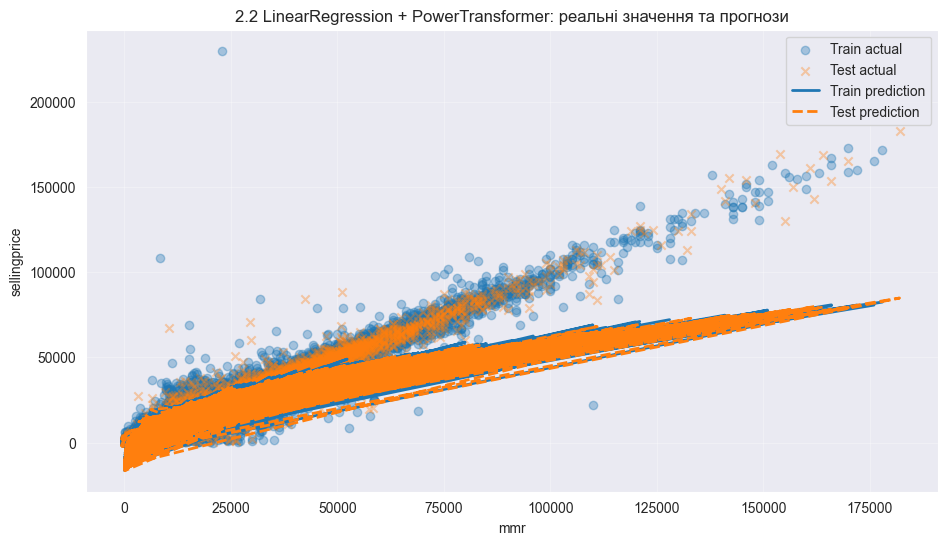

In [143]:
plot_single_model_predictions(
    X_train[top_feature], X_test[top_feature],
    y_train, y_test,
    y_train_pred_lin_pt, y_test_pred_lin_pt,
    top_feature, "2.2 LinearRegression + PowerTransformer"
)

Як можна побачити з графіку, точки прогнозу гірше збігаються з реальними значеннями, є навіть візуальне відхилення в сторону значень передбачень після нормалізації. У рамках метрик, то теж прослідковується погіршення:

- `R^2` = 0.89 (було 0.97) не значно погіршилось
- `MSE` = 2000 (було 1000) збільшилось вдвічі менша точність

## 2.3 Гребенева регресія

Будуємо 3 моделі:
- `Ridge(alpha=1.0)` — значення за замовчуванням;
- `Ridge(alpha=0.1)` — слабша регуляризація (допомагає зменшити перенавчання та стабілізує ваги моделі);
- `Ridge(alpha=10.0)` — сильніша регуляризація.

In [148]:
ridge_default = Ridge()            # alpha=1.0 за замовчуванням
ridge_alpha_01 = Ridge(alpha=0.1)
ridge_alpha_10 = Ridge(alpha=10.0)

ridge_models = {
    "Ridge alpha=1.0": ridge_default,
    "Ridge alpha=0.1": ridge_alpha_01,
    "Ridge alpha=10.0": ridge_alpha_10
}

ridge_23_results = []
ridge_23_predictions = {}

for name, model in ridge_models.items():
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    row = full_metrics_dict(y_train, train_pred, y_test, test_pred)
    row["Train_R2_score"] = train_score
    row["Test_R2_score"] = test_score

    ridge_23_results.append(pd.Series(row, name=name))
    ridge_23_predictions[name] = (train_pred, test_pred)


metrics_23 = pd.DataFrame(ridge_23_results)
metrics_23

,Train_R2,Test_R2,Train_MAE,Test_MAE,Train_MSLE,Test_MSLE,Train_D2,Test_D2,Train_R2_score,Test_R2_score
Ridge alpha=1.0,0.969675,0.970231,1053.109393,1063.877123,0.206299,0.19957,0.849929,0.848828,0.969675,0.970231
Ridge alpha=0.1,0.969675,0.970231,1053.109393,1063.877124,0.206299,0.19957,0.849929,0.848828,0.969675,0.970231
Ridge alpha=10.0,0.969675,0.970231,1053.109385,1063.877115,0.206299,0.19957,0.849929,0.848828,0.969675,0.970231


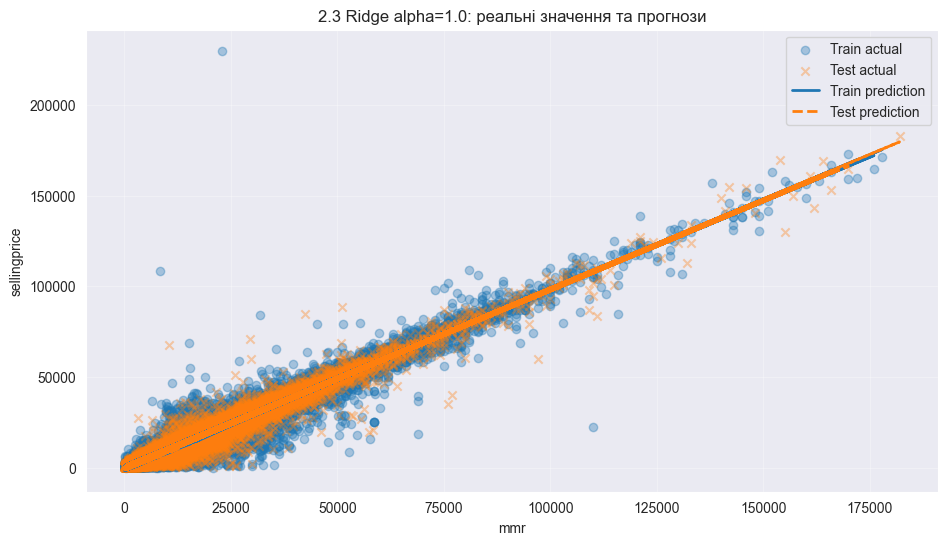

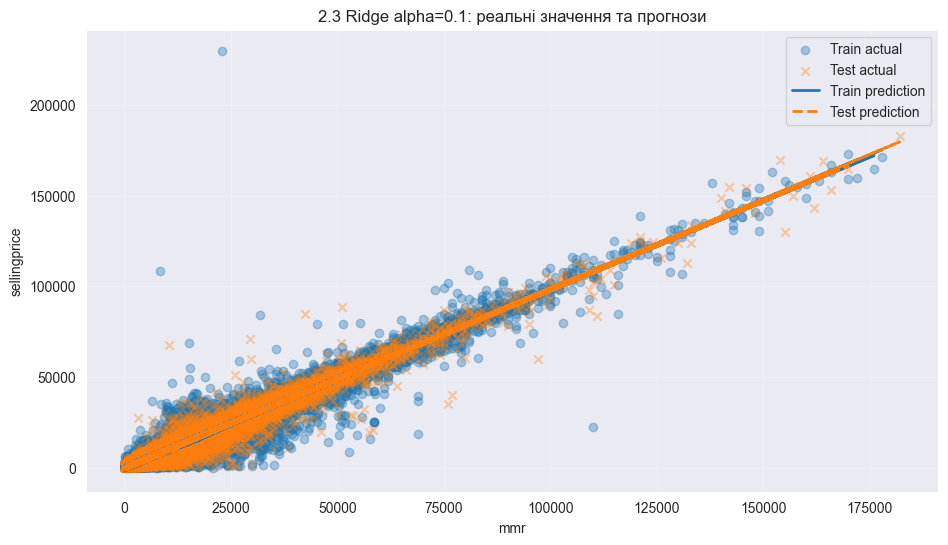

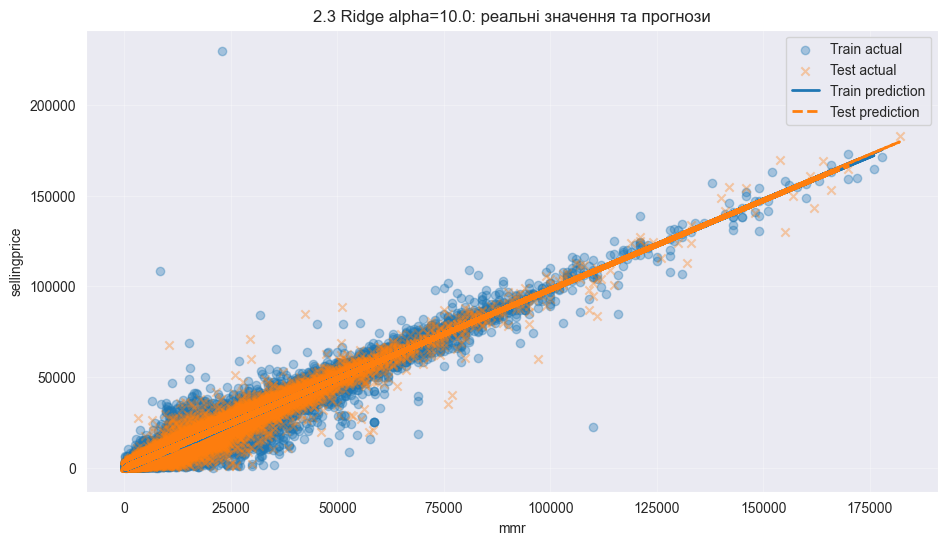

In [149]:
for name, (train_pred, test_pred) in ridge_23_predictions.items():
    plot_single_model_predictions(
        X_train[top_feature], X_test[top_feature],
        y_train, y_test,
        train_pred, test_pred,
        top_feature, f"2.3 {name}"
    )

Графки при всіх значеннях `alpha` на вигляд ідентичні та показали доволі точний результат. Якщо порівняти з 2.1, то графіки та значення метрик повторюються

## 2.4 Гребенева регресія з перетворенням змінних

Аналогічно 2.2 повторюємо навчання, виконуємо `PowerTransformer` для ознак і цільової змінної.


In [150]:
ridge_models_pt = {
    "Ridge+PT alpha=1.0": Ridge(),
    "Ridge+PT alpha=0.1": Ridge(alpha=0.1),
    "Ridge+PT alpha=10.0": Ridge(alpha=10.0)
}

ridge_24_results = []
ridge_24_predictions = {}

for name, model in ridge_models_pt.items():
    # навчання на трансформованих ознаках, але оригінальній цільовій змінній
    model.fit(X_train_pt, y_train)

    # вбудована метрика .score()
    train_score = model.score(X_train_pt, y_train)
    test_score = model.score(X_test_pt, y_test)

    # прогнози
    train_pred = model.predict(X_train_pt)
    test_pred = model.predict(X_test_pt)

    # усі метрики в одному просторі — початковому
    row = full_metrics_dict(y_train, train_pred, y_test, test_pred)
    row["Train_R2_score"] = train_score
    row["Test_R2_score"] = test_score

    ridge_24_results.append(pd.Series(row, name=name))
    ridge_24_predictions[name] = (train_pred, test_pred)

metrics_24 = pd.DataFrame(ridge_24_results)
metrics_24

,Train_R2,Test_R2,Train_MAE,Test_MAE,Train_MSLE,Test_MSLE,Train_D2,Test_D2,Train_R2_score,Test_R2_score
Ridge+PT alpha=1.0,0.89228,0.889050,2001.585048,2017.410181,3.813427,3.843453,0.714768,0.713335,0.89228,0.889050
Ridge+PT alpha=0.1,0.89228,0.889050,2001.590352,2017.415454,3.813447,3.843480,0.714768,0.713335,0.89228,0.889050
Ridge+PT alpha=10.0,0.89228,0.889049,2001.532030,2017.357494,3.813226,3.843169,0.714776,0.713343,0.89228,0.889049


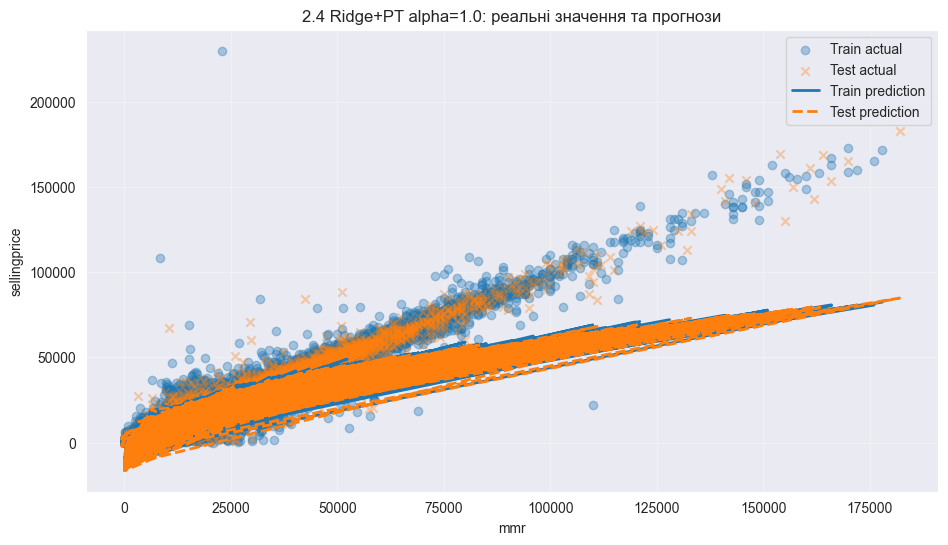

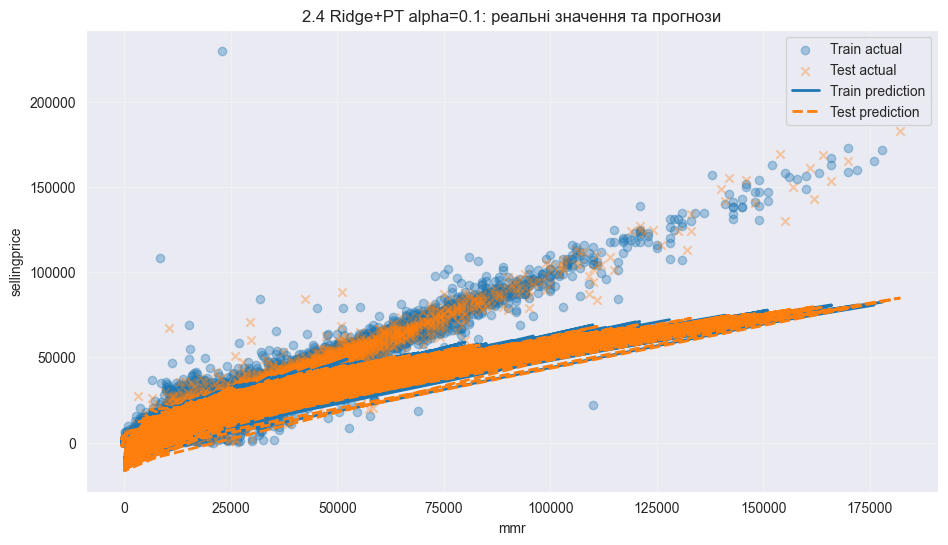

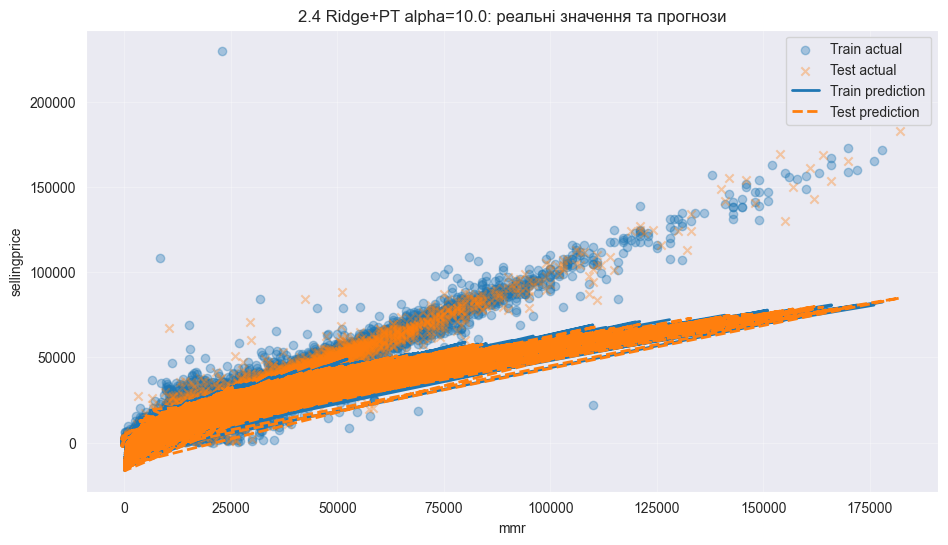

In [151]:
for name, (train_pred, test_pred) in ridge_24_predictions.items():
    plot_single_model_predictions(
        X_train[top_feature], X_test[top_feature],
        y_train, y_test,
        train_pred, test_pred,
        top_feature, f"2.4 {name}"
    )

Результати аналогічні до пункту 2.2 після нормалізації даних, точність погіршилась, метрики та графіки ідентичні до 2.2

## 2.5 Сукупне порівняння метрик
Збираємо фінальний DataFrame (червоний — менші значення; зелений — більші значення)

In [152]:
all_metrics = pd.concat([
    metrics_21,
    metrics_22,
    metrics_23,
    metrics_24
], axis=0)

all_metrics

,Train_R2,Test_R2,Train_MAE,Test_MAE,Train_MSLE,Test_MSLE,Train_D2,Test_D2,Train_R2_score,Test_R2_score
2.1 LinearRegression,0.969675,0.970231,1053.109394,1063.877124,0.206299,0.199570,0.849929,0.848828,0.969675,0.970231
2.2 LinearRegression + PowerTransformer,0.892280,0.889050,2001.590942,2017.416040,3.813449,3.843483,0.714768,0.713335,0.892280,0.889050
Ridge alpha=1.0,0.969675,0.970231,1053.109393,1063.877123,0.206299,0.199570,0.849929,0.848828,0.969675,0.970231
Ridge alpha=0.1,0.969675,0.970231,1053.109393,1063.877124,0.206299,0.199570,0.849929,0.848828,0.969675,0.970231
Ridge alpha=10.0,0.969675,0.970231,1053.109385,1063.877115,0.206299,0.199570,0.849929,0.848828,0.969675,0.970231
Ridge+PT alpha=1.0,0.892280,0.889050,2001.585048,2017.410181,3.813427,3.843453,0.714768,0.713335,0.892280,0.889050
Ridge+PT alpha=0.1,0.892280,0.889050,2001.590352,2017.415454,3.813447,3.843480,0.714768,0.713335,0.892280,0.889050
Ridge+PT alpha=10.0,0.892280,0.889049,2001.532030,2017.357494,3.813226,3.843169,0.714776,0.713343,0.892280,0.889049


In [153]:
styled_metrics = all_metrics.style.background_gradient(cmap="RdYlGn", axis=None).format("{:.6f}")
styled_metrics

,Train_R2,Test_R2,Train_MAE,Test_MAE,Train_MSLE,Test_MSLE,Train_D2,Test_D2,Train_R2_score,Test_R2_score
2.1 LinearRegression,0.969675,0.970231,1053.109394,1063.877124,0.206299,0.199570,0.849929,0.848828,0.969675,0.970231
2.2 LinearRegression + PowerTransformer,0.892280,0.889050,2001.590942,2017.416040,3.813449,3.843483,0.714768,0.713335,0.892280,0.889050
Ridge alpha=1.0,0.969675,0.970231,1053.109393,1063.877123,0.206299,0.199570,0.849929,0.848828,0.969675,0.970231
Ridge alpha=0.1,0.969675,0.970231,1053.109393,1063.877124,0.206299,0.199570,0.849929,0.848828,0.969675,0.970231
Ridge alpha=10.0,0.969675,0.970231,1053.109385,1063.877115,0.206299,0.199570,0.849929,0.848828,0.969675,0.970231
Ridge+PT alpha=1.0,0.892280,0.889050,2001.585048,2017.410181,3.813427,3.843453,0.714768,0.713335,0.892280,0.889050
Ridge+PT alpha=0.1,0.892280,0.889050,2001.590352,2017.415454,3.813447,3.843480,0.714768,0.713335,0.892280,0.889050
Ridge+PT alpha=10.0,0.892280,0.889049,2001.532030,2017.357494,3.813226,3.843169,0.714776,0.713343,0.892280,0.889049
